# In-sample ceiling: is near-perfect AUC even possible?

Two questions:

1. Can our features separate the labels *at all*? Test: train a deliberately
   big model and evaluate on the same data it trained on (in-sample).
2. How does that compare to honest, out-of-sample performance per year?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score

In [2]:
DATA = "data/kernel"

price = pd.read_csv(f"{DATA}/Historical_day_ahead_price_2015_2025.csv")
inflow = pd.read_csv(f"{DATA}/Historical_inflow_1958_2025.csv")
volume = pd.read_csv(f"{DATA}/Historical_volume_2015_2024.csv")
water = pd.read_csv(f"{DATA}/Synthetic_water_value_2015_2024.csv")
target = pd.read_csv(f"{DATA}/Unit_commitment_decisions.csv")

In [3]:
# one hourly grid: price as hourly mean, inflow + climatology, daily tables
p = price.copy()
p["date"] = pd.to_datetime(p["date"], utc=True, format="mixed")
price_h = p.set_index("date")["Day-ahead price (EUR/MWh)"].sort_index().resample("1h").mean()

inf = inflow.copy()
inf["date"] = pd.to_datetime(inf["date"], utc=True, format="mixed")
inf_wide = inf.set_index("date")
old = inf_wide[:"2014"]
clim = old.groupby(old.index.dayofyear).mean()
inf_anom = inf_wide - clim.reindex(inf_wide.index.dayofyear).to_numpy()

vol = volume.copy()
vol["date"] = pd.to_datetime(vol["date"], utc=True, format="mixed")
vol_wide = vol.set_index("date")
wv = water.copy()
wv["date"] = pd.to_datetime(wv["date"], utc=True, format="mixed")
wv_wide = wv.set_index("date")

In [4]:
# plant -> intake reservoir, and upstream chains, from Tokke_Vinje_topology.yaml
PLANT_RESERVOIR = {
    "Tokke": "Vinjevatn",
    "Vinje": "Vaamarvatn",
    "Hogga": "Bandak",
    "Lio": "Byrtevatn",
    "Byrte": "Botnedalsvatn",
    "Kjela": "Foersvatn",
    "Songa": "Songavatn",
    "Haukeli": "Vatjern",
    "Vesle Kjela": "Kjelavatn",
}

UPSTREAM = {
    "Tokke": ["Vinjevatn", "Vaamarvatn", "Totak", "Venemo"],
    "Vinje": ["Vaamarvatn", "Totak", "Venemo"],
    "Hogga": ["Bandak"],
    "Lio": ["Byrtevatn"],
    "Byrte": ["Botnedalsvatn"],
    "Kjela": ["Foersvatn", "Bordalsvatn"],
    "Songa": ["Songavatn", "Bitdalsvatn"],
    "Haukeli": ["Vatjern"],
    "Vesle Kjela": ["Kjelavatn"],
}

In [5]:
# long table: one row per (case, unit, hour)
result_cols = [c for c in target.columns if c.startswith("result_committed")]

labels = target.melt(id_vars=["Run No"], value_vars=result_cols, value_name="on")
labels["unit_id"] = labels["variable"].str.removeprefix("result_committed_").str.replace(
    r"_t\d+$", "", regex=True
)
labels["t"] = labels["variable"].str.extract(r"_t(\d+)$").astype("int16")
labels["on"] = labels["on"].astype("int8")
labels = labels.drop(columns="variable")

In [6]:
starts = pd.to_datetime(target["starttime"], utc=True, format="mixed")

grid = pd.DataFrame(
    {
        "Run No": np.repeat(target["Run No"].to_numpy(), 168),
        "t": np.tile(np.arange(168), len(target)),
    }
)
grid["timestamp"] = pd.to_datetime(np.repeat(starts.to_numpy(), 168), utc=True) + pd.to_timedelta(
    grid["t"], unit="h"
)
grid["price"] = price_h.reindex(grid["timestamp"]).to_numpy()
grid["hour"] = grid["timestamp"].dt.hour
grid["dow"] = grid["timestamp"].dt.dayofweek
grid["month"] = grid["timestamp"].dt.month
grid["date"] = grid["timestamp"].dt.floor("D")

labels = labels.merge(grid, on=["Run No", "t"], how="left")
labels["starttime"] = labels["Run No"].map(dict(zip(target["Run No"], starts)))

In [7]:
# per-unit reservoir features + upstream chain features
labels["plant"] = labels["unit_id"].str.replace(r"_G\d+$", "", regex=True)
labels["reservoir"] = labels["plant"].map(PLANT_RESERVOIR).astype("category")


def pick(wide, key, name):
    labels[name] = np.nan
    for res, g in labels.groupby("reservoir", observed=True):
        labels.loc[g.index, name] = wide[res].reindex(g[key]).to_numpy()


pick(inf_wide, "timestamp", "inflow_res")
pick(inf_anom, "timestamp", "inflow_anom")
pick(vol_wide, "date", "vol_res")
pick(wv_wide, "date", "wv_res")

up_inflow = {pl: inf_wide[ups].sum(axis=1) for pl, ups in UPSTREAM.items()}
up_wv = {pl: wv_wide[ups].min(axis=1) for pl, ups in UPSTREAM.items()}
labels["up_inflow_sum"] = np.nan
labels["up_wv_min"] = np.nan
for pl, g in labels.groupby("plant", observed=True):
    labels.loc[g.index, "up_inflow_sum"] = up_inflow[pl].reindex(g["timestamp"]).to_numpy()
    labels.loc[g.index, "up_wv_min"] = up_wv[pl].reindex(g["date"]).to_numpy()

In [8]:
# case-level features + case context (the optimizer sees the whole week)
case_res = labels[["Run No", "reservoir", "starttime"]].drop_duplicates(["Run No", "reservoir"])
case_res["init_vol"] = [
    vol_wide.at[s.floor("D"), r] for s, r in zip(case_res.starttime, case_res.reservoir)
]
case_res["end_wv"] = [
    wv_wide.at[(s + pd.Timedelta(days=8)).floor("D"), r]
    for s, r in zip(case_res.starttime, case_res.reservoir)
]
labels = labels.merge(
    case_res[["Run No", "reservoir", "init_vol", "end_wv"]],
    on=["Run No", "reservoir"],
    how="left",
)
labels["margin"] = labels["price"] - labels["wv_res"]

g = labels.groupby("Run No")
labels["price_mean"] = g["price"].transform("mean")
labels["price_rel"] = labels["price"] - labels["price_mean"]
labels["price_pct"] = g["price"].rank(pct=True)
labels["margin_mean"] = g["margin"].transform("mean")
labels["margin_rel"] = labels["margin"] - labels["margin_mean"]

labels["unit_id"] = labels["unit_id"].astype("category")
labels["plant"] = labels["plant"].astype("category")

FEATS = [
    "price", "margin", "t", "hour", "dow", "month",
    "inflow_res", "inflow_anom", "vol_res", "wv_res",
    "init_vol", "end_wv", "up_inflow_sum", "up_wv_min",
    "price_mean", "price_rel", "price_pct", "margin_mean", "margin_rel",
]
X = FEATS + ["unit_id"]
print(labels.shape)

(6872544, 27)


## 1. In-sample: can a big model memorize the labels from these features?

In [9]:
split = pd.Timestamp("2022-01-01", tz="UTC")
train = labels[labels["starttime"] < split].reset_index(drop=True)

sub = train.sample(1_500_000, random_state=0).reset_index(drop=True)

big = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=10,
    tree_method="hist", enable_categorical=True, eval_metric="auc",
)
big.fit(sub[X], sub["on"])

in_sample = roc_auc_score(sub["on"], big.predict_proba(sub[X])[:, 1])
print("in-sample AUC:", round(in_sample, 4))

in-sample AUC: 0.9985


AUC ~ 0.999 in-sample means the features contain (almost) all the information
needed to determine the commitment decisions. The problem is not missing inputs,
it is **generalization**: the same mapping must hold for weeks the model has never seen.

## 2. Out-of-sample: AUC per year

In [10]:
# honest model: train on 2015-2021, then score every year separately
clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6, min_child_weight=50,
    subsample=0.8, colsample_bytree=0.8, tree_method="hist",
    enable_categorical=True, eval_metric="auc", early_stopping_rounds=30,
)
val = labels[labels["starttime"] >= split].reset_index(drop=True)
clf.fit(train[X], train["on"], eval_set=[(val[X], val["on"])], verbose=False)

pred = clf.predict_proba(labels[X])[:, 1]
labels["pred"] = pred

per_year = labels.groupby(labels["starttime"].dt.year).apply(
    lambda g: roc_auc_score(g["on"], g["pred"])
)
print(per_year.round(4))

starttime
2015    0.9402
2016    0.9336
2017    0.9360
2018    0.9194
2019    0.9260
2020    0.9427
2021    0.9307
2022    0.8753
dtype: float64


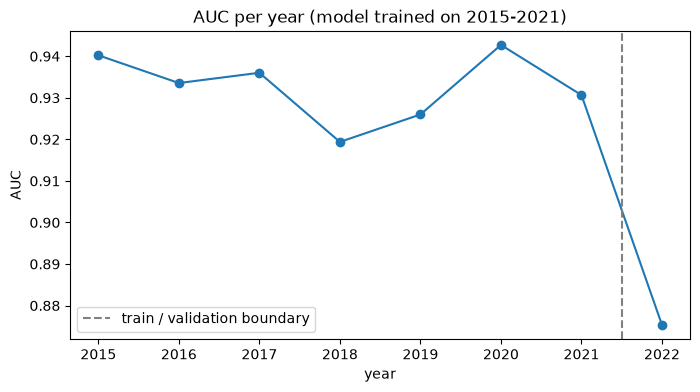

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(per_year.index, per_year.values, marker="o")
plt.axvline(2021.5, color="gray", linestyle="--", label="train / validation boundary")
plt.xlabel("year")
plt.ylabel("AUC")
plt.title("AUC per year (model trained on 2015-2021)")
plt.legend()
plt.show()

## Takeaways

- In-sample AUC ~ 0.999: the features are (nearly) sufficient to determine the
  labels. Near-perfect AUC is *possible* in principle.
- The honest model scores ~ 0.92-0.94 on the years it trained on, and 0.875 on
  the held-out 2022. The big model shows the ceiling is ~ 0.999, so the whole
  gap is generalization, not information.
- The per-year trend also shows the system drifting over time, so the newest
  year is always the hardest. That is why the rolling-origin notebook and a
  final retrain on all years matter.